# TP3 — Lectura y Discovery: Sentiment140

**Alumno:** Gonzalo Zarazaga

---

## Dataset: Sentiment140

El corpus se distribuye en **dos archivos** con propósitos distintos:

| Archivo | Registros | Etiquetado | Uso previsto |
|---|---|---|---|
| `training.1600000.processed.noemoticon.csv` | ~1.6M | Automático (por emoticon), 2 clases (0/4) | Entrenamiento y evaluación (**obligatorio usarlo completo**) |
| `testdata.manual.2009.06.14.csv` | ~500 | Manual (humano), 3 clases (0/2/4) | Candidato a test externo — a decidir en este notebook |

### Diccionario de columnas (sin header en el CSV original)

| Columna | Descripción |
|---|---|
| `polarity` | Polaridad del tweet: 0=negativo, 2=neutral, 4=positivo |
| `id` | ID del tweet |
| `date` | Fecha de publicación |
| `query` | Query usada para recolectar el tweet (`NO_QUERY` si no aplica) |
| `user` | Usuario que publicó el tweet |
| `text` | Texto del tweet |

**Insumo:** `data/raw/training.1600000.processed.noemoticon.csv`, `data/raw/testdata.manual.2009.06.14.csv`  
**Salida:** decisión documentada sobre el uso del archivo chico, para `01_preprocesamiento.ipynb`

## 1. Lectura de ambos datasets

Los archivos no traen encabezado y están codificados en `latin-1` (no `utf-8`), como es habitual en el dump original de Sentiment140.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

COLS = ["polarity", "id", "date", "query", "user", "text"]

df_train = pd.read_csv("../data/raw/training.1600000.processed.noemoticon.csv", encoding="latin-1", names=COLS)
df_test_manual = pd.read_csv("../data/raw/testdata.manual.2009.06.14.csv", encoding="latin-1", names=COLS)

print(f"training.1600000...csv: {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas")
print(f"testdata.manual...csv:  {df_test_manual.shape[0]:,} filas × {df_test_manual.shape[1]} columnas")

training.1600000...csv: 1,600,000 filas × 6 columnas
testdata.manual...csv:  498 filas × 6 columnas


In [2]:
df_train.head(3)

,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [3]:
df_test_manual.head(3)

,polarity,id,date,query,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."


## 2. Estructura y calidad de datos

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   polarity  1600000 non-null  int64 
 1   id        1600000 non-null  int64 
 2   date      1600000 non-null  object
 3   query     1600000 non-null  object
 4   user      1600000 non-null  object
 5   text      1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [5]:
for nombre, df in [("train (1.6M)", df_train), ("test manual (500)", df_test_manual)]:
    print(f"--- {nombre} ---")
    print(f"Nulos totales:        {df.isna().sum().sum()}")
    print(f"Filas duplicadas:     {df.duplicated().sum()}")
    print(f"Texto duplicado:      {df['text'].duplicated().sum()}")
    print(f"Valores de query:     {df['query'].nunique()} únicos")
    print()

--- train (1.6M) ---


Nulos totales:        0


Filas duplicadas:     0
Texto duplicado:      18534
Valores de query:     1 únicos

--- test manual (500) ---
Nulos totales:        0
Filas duplicadas:     0
Texto duplicado:      0
Valores de query:     81 únicos



No hay valores nulos en ninguno de los dos archivos. El archivo grande tiene texto duplicado (retweets / spam), algo esperable en un corpus recolectado automáticamente por streaming — se evaluará en `01_preprocesamiento.ipynb` si conviene deduplicar antes de entrenar Word2Vec.

## 3. Distribución de la variable objetivo (`polarity`)

Este es el punto central del discovery: **los dos archivos no tienen el mismo esquema de etiquetas.**

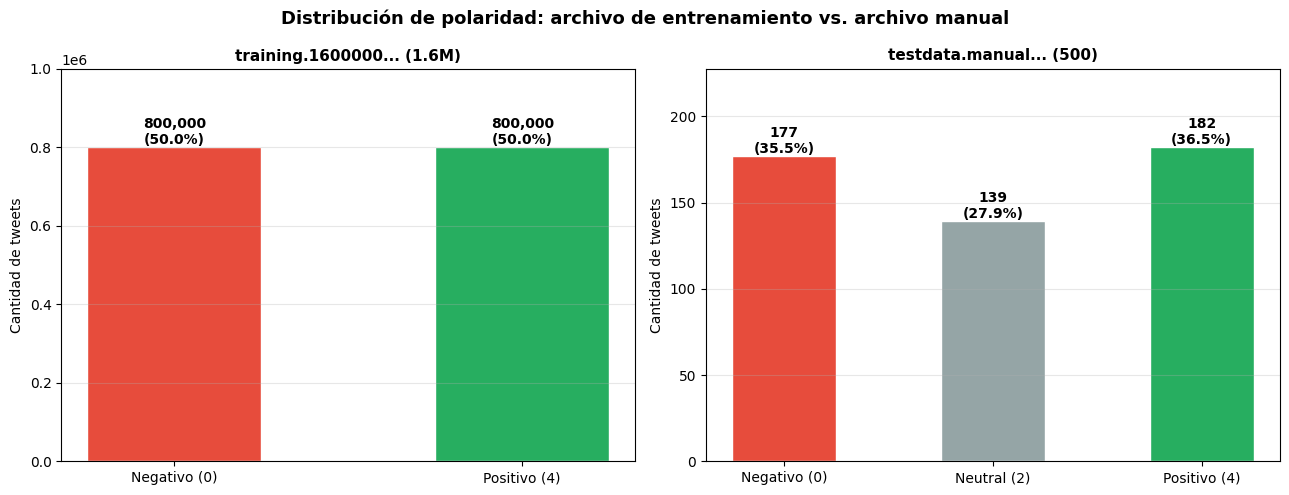

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels_map = {0: "Negativo (0)", 2: "Neutral (2)", 4: "Positivo (4)"}
colores_map = {0: "#e74c3c", 2: "#95a5a6", 4: "#27ae60"}

for ax, (nombre, df) in zip(axes, [("training.1600000... (1.6M)", df_train), ("testdata.manual... (500)", df_test_manual)]):
    conteo = df["polarity"].value_counts().sort_index()
    prop = df["polarity"].value_counts(normalize=True).sort_index() * 100
    etiquetas = [labels_map[p] for p in conteo.index]
    colores = [colores_map[p] for p in conteo.index]

    bars = ax.bar(etiquetas, conteo.values, color=colores, edgecolor="white", width=0.5)
    for bar, p in zip(bars, prop.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{int(bar.get_height()):,}\n({p:.1f}%)", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    ax.set_title(nombre, fontsize=11, fontweight="bold")
    ax.set_ylabel("Cantidad de tweets")
    ax.set_ylim(0, conteo.max() * 1.25)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribución de polaridad: archivo de entrenamiento vs. archivo manual", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
print("training.1600000...csv — clases presentes:", sorted(df_train["polarity"].unique()))
print("testdata.manual...csv  — clases presentes:", sorted(df_test_manual["polarity"].unique()))
print()
pct_neutral = (df_test_manual["polarity"] == 2).mean() * 100
print(f"% de neutros en el archivo manual: {pct_neutral:.1f}%")

training.1600000...csv — clases presentes: [np.int64(0), np.int64(4)]
testdata.manual...csv  — clases presentes: [np.int64(0), np.int64(2), np.int64(4)]

% de neutros en el archivo manual: 27.9%


**Hallazgo clave:** el archivo grande (obligatorio) es **binario** (0/4) — nunca vio la clase neutral durante el etiquetado automático por emoticones. El archivo chico es un test **manual** de tres clases, con ~28% de tweets neutros. Cualquier modelo entrenado sobre el archivo grande es estructuralmente incapaz de predecir "neutral": no es una clase que pueda aparecer en sus probabilidades de salida sin inventar un criterio adicional.

## 4. Ventana temporal (relevante para el diferenciador de tópicos)

In [8]:
fechas_train = pd.to_datetime(df_train["date"].str.replace(" PDT", "", regex=False), format="%a %b %d %H:%M:%S %Y")
print(f"Rango de fechas (train): {fechas_train.min()} → {fechas_train.max()}")
print(f"Duración: {(fechas_train.max() - fechas_train.min()).days} días")

Rango de fechas (train): 2009-04-06 22:19:45 → 2009-06-25 10:28:31
Duración: 79 días


El corpus grande cubre del **6 de abril al 25 de junio de 2009** — el límite superior coincide exactamente con la fecha de la muerte de Michael Jackson (25/6/2009). Esto valida la hipótesis del análisis temporal de tópicos propuesto como diferenciador (ver README, sección "Diferenciador — Análisis temporal de tópicos").

## 5. Decisión: qué hacer con `testdata.manual.2009.06.14.csv`

Consigna del profesor: el archivo grande es de uso obligatorio; el chico es opcional y tiene ~25-28% de registros neutros que ningún modelo entrenado en el archivo grande puede predecir. Se evaluaron cuatro alternativas:

| Opción | Descripción | Motivo de descarte / aceptación |
|---|---|---|
| **A.** No usar el archivo chico | Se pierde el único test etiquetado a mano del dataset — el archivo grande está etiquetado automáticamente por emoticones, con ruido conocido (sarcasmo, negaciones). Descartar el único ground truth humano es desperdiciar la validación más confiable disponible. | Descartada |
| **B. Sacar los registros neutros** | De 498 registros quedan ~359 (0 y 4). Se usa como **test externo** (out-of-sample, etiquetado humano), nunca como train — 359 filas no aportan nada entrenando junto a 1.6M. | **Elegida** |
| **C.** Usar el archivo completo (3 clases) y hacer split train/test sobre él | Con ~500 filas, un split deja porciones de decenas de registros por clase — la métrica de precisión resultante tendría varianza altísima y no sería representativa. Además el modelo principal es binario, se estaría bajando de una tarea con 1.6M ejemplos a una con cientos. | Descartada |
| **D.** Entrenar un modelo binario y discretizarlo en 3 clases | Requiere inventar un umbral de "zona neutral" sobre la probabilidad del clasificador binario (ej. 0.4–0.6 → neutral) sin ningún dato de entrenamiento que respalde ese corte — es una heurística no validada que agrega complejidad y un grado de libertad arbitrario al pipeline. | Descartada por ahora (queda como posible trabajo futuro/nota, no como parte del pipeline principal) |

### Decisión adoptada

Se opta por la **opción B**: filtrar `polarity != 2` en `testdata.manual.2009.06.14.csv` (quedan ~359 registros) y usarlo exclusivamente como **segundo test set, independiente del split del archivo grande**, para validar si los modelos entrenados con etiquetas automáticas (por emoticon) generalizan a etiquetas puestas por un humano. Los registros neutros (~139) se descartan del pipeline de clasificación de sentimiento, pero no se pierden del todo: quedan disponibles como candidatos para el análisis exploratorio de tópicos/keywords (Enfoque 2 / diferenciador), donde la etiqueta de polaridad no es un requisito.

### Por qué se filtran los neutros (resumen)

El archivo grande se etiquetó por *distant supervision* (emoticon), un proceso que nunca produjo un ejemplo neutral — los modelos entrenados ahí no tienen ninguna noción de esa clase en su frontera de decisión. Incluir neutros en la evaluación, o inventar un umbral que los discretice (opción D), es forzar un supuesto no validado: no hay datos de entrenamiento que respalden dónde debería ir ese corte. Filtrarlos no es descartar información porque sí, es reconocer que "neutral" es una categoría que solo existe en el juicio humano del archivo manual, no en la tarea que el modelo efectivamente aprendió.

### Verificación: ¿el archivo manual es realmente independiente?

Para que el archivo manual filtrado sirva como test *out-of-sample*, no puede haber tweets que también estén en el archivo de entrenamiento.

In [9]:
test_manual_bin = df_test_manual[df_test_manual["polarity"] != 2]

overlap_text = test_manual_bin["text"].isin(set(df_train["text"])).sum()
overlap_id = test_manual_bin["id"].isin(set(df_train["id"])).sum()

print(f"Registros binarios en el archivo manual (sin neutros): {len(test_manual_bin)}")
print(f"Solapamiento por texto con el archivo de entrenamiento: {overlap_text}")
print(f"Solapamiento por id con el archivo de entrenamiento:    {overlap_id}")

Registros binarios en el archivo manual (sin neutros): 359
Solapamiento por texto con el archivo de entrenamiento: 0
Solapamiento por id con el archivo de entrenamiento:    0


**Resultado:** 0 solapamientos, ni por texto ni por id — el archivo manual filtrado (359 registros) es un conjunto genuinamente independiente del archivo de entrenamiento.

### Regla de implementación (resumen)

El archivo manual filtrado **nunca pasa por `.fit()`** de ningún componente (ni `Word2Vec`, ni `CountVectorizer`/`TfidfVectorizer`, ni el clasificador). Todo se ajusta exclusivamente sobre el split del archivo grande; el archivo manual solo se usa en modo `.transform()` / `.predict()`, es decir, en inferencia. Bajo esa disciplina, filtrar sus neutros no toca ningún parámetro aprendido — sólo cambia qué filas se usan para *medir* el modelo después de entrenado.